<a href="https://colab.research.google.com/github/pattyymat/data_analyst_projects/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:
**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**
> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel ingreso`
- `visitas mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso anual`

La mayoría de estas variables presentan tipos de datos adecuados, a excepción de la columna `edad` que tiene tipo de dato float y debería ser int.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] =  df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
col_numericas=['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[col_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**:

**Diagnóstico inicial de variables numéricas**

- **`edad`** — la edad promedio es de 38.2, con un rango amplio entre 18 y 75 años lo que indica una base de datos diversa en terminos generacionales. El 50% de los clientes tienen entre 30 y 46 años.
- **`nivel de ingreso`**- el promedio de ingreso es de 30019.70 muy cercano al valor de la mediana (30023,75), lo que sugiere una distribución relativamente simétrica y sin una fuerte influencia de valores extremos.
- **`visitas_mes`**- Los clientes realizan en promedio 10 visitas al mes. La mayoría visita la plataforma entre 8 y 12 veces, reflejando un comportamiento bastante consistente.
- **`compras_mes`**- Aunque el promedio es de 1.2 compras mensuales, la mediana es 1 compra y el primer cuartil es 0, indicando que una proporción importante de usuarios no compra todos los meses.
- **`gasto_publicidad_dirigida`**- El gasto promedio en publicidad es de 20.15, con valores entre 0 y 75.51. Existen clientes que no reciben publicidad dirigida, mientras que otros reciben una inversión considerablemente mayor.
- **`satisfaccion`**- La satisfacción promedio es de 3.6 sobre 5, lo que indica una percepción generalmente positiva. La mitad de los clientes califica el servicio entre 3.1 y 4.1.
- **`ingreso_anual`**- El ingreso anual presenta la mayor variabilidad del conjunto (std 34.48). Además, el 25% de los clientes registra un ingreso anual de 0, lo que sugiere que muchos usuarios aún no generan ingresos o no han realizado compras, mientras que algunos alcanzan hasta 244.69, indicando una distribución sesgada hacia valores altos.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
col_binarias = ['miembro_premium', 'abandono']
df[col_binarias].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
dtype: int64

✍️ **Comentario**:

**Diagnóstico inicial de variables binarias**

- `miembro_premium` — La gran mayoría de los clientes no pertenece al programa premium (12911), mientras que solo 2089 clientes son miembros premium. Esto confirma que la membresía premium representa un segmento reducido de la base de clientes.
- `abandono` — El abandono es considerablemente menor entre los clientes premium. Solo 91 de 2089 miembros premium abandonaron el servicio, frente a 2170 de 12911 clientes no premium. Esto sugiere que pertenecer al programa premium está asociado con una mayor retención de clientes.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
col_categoricas= ['tipo_dispositivo', 'region']
df[col_categoricas].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
df[col_categoricas].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

✍️ **Comentario**:

**Diagnóstico inicial de variables categóricas**

- **`tipo_dispositivo`** — El móvil es, por mucho, el dispositivo más utilizado, con 9818 clientes (65.5%), seguido por escritorio con 3720 (24.8%) y tablet con 1462 (9.7%). Esto indica que la mayor parte de la interacción con la plataforma ocurre desde dispositivos móviles.
- **`region`** - La región norte concentra la mayor cantidad de clientes (4395; 29.3%), seguida de oeste (3810; 25.4%), sur (3726; 24.8%) y este (3069; 20.5%). Aunque todas las regiones tienen una representación importante, la región este cuenta con la menor cantidad de usuarios.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

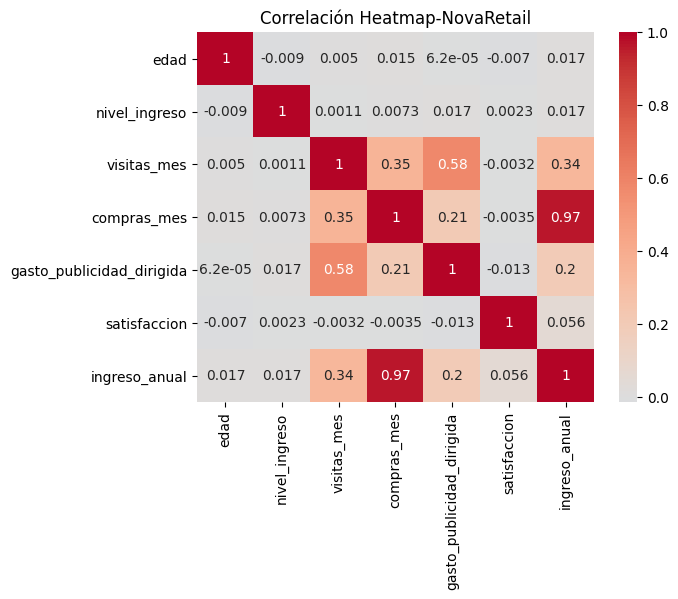

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[col_numericas].corr()
#plt.figure(figsize=(10,6))
sns.heatmap(corr, annot= True, cmap="coolwarm", center=0)
plt.title("Correlación Heatmap-NovaRetail")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves

Observaciones generales (Heatmap)  
- Se observa que las variables como edad, nivel_ingreso y satisfaccion prácticamente no tienen ninguna relación lineal entre sí ni con el comportamiento de compra, ya que los valores son cercanos a cero.
- Existe un bloque central de correlaciones moderadas y fuertes entre tres variables específicas: visitas_mes, compras_mes y gasto_publicidad_dirigida. Hay una relación moderada-alta (0.58) entre las visitas mensuales y el gasto en publicidad dirigida. Hay una relación moderada (0.35) entre las visitas mensuales y las compras mensuales.

Observaciones respecto a `ingreso_anual`  
- Presenta **correlación fuerte** con compras_mes (0.97): Es la relación más fuerte de todo el gráfico. Esto indica que a mayor ingreso anual, el número de compras al mes aumenta de forma casi lineal y directa.
- **Correlación moderada** con visitas_mes (0.34): Los usuarios con mayor ingreso anual tienden a visitar más veces la plataforma al mes, lo cual tiene sentido dado que también son los que más compran.
- **Correlación débil** con gasto_publicidad_dirigida (0.2): Existe una relación positiva pero muy pequeña. El nivel de ingresos anuales no está fuertemente condicionado por la publicidad dirigida que recibe el usuario o viceversa.
- **Correlación nula** con la edad (0.017), con el nivel_ingreso (0.017), tampoco influye en la satisfaccion (0.056).


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- No es necesario generar un scatterplot general debido a que, en el Heatmap se visualizan ya los pares de variables que mostraron un comportamiento interesante y que deberían analizarse a profundidad.

### Scatterplot para pares clave

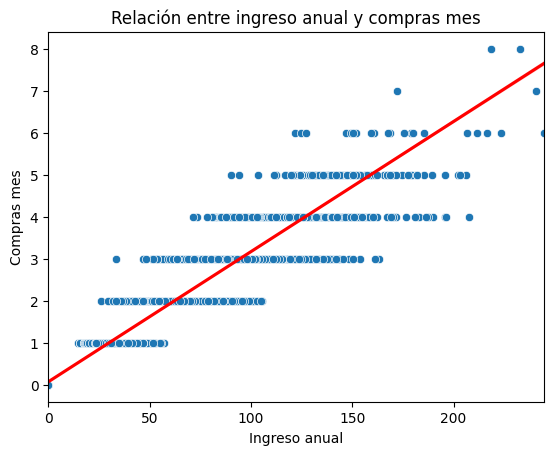

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='ingreso_anual', y='compras_mes')
sns.regplot(data=df, x='ingreso_anual', y='compras_mes', scatter=False, color='red')
plt.title("Relación entre ingreso anual y compras mes")
plt.xlabel("Ingreso anual")
plt.ylabel("Compras mes")
plt.show()

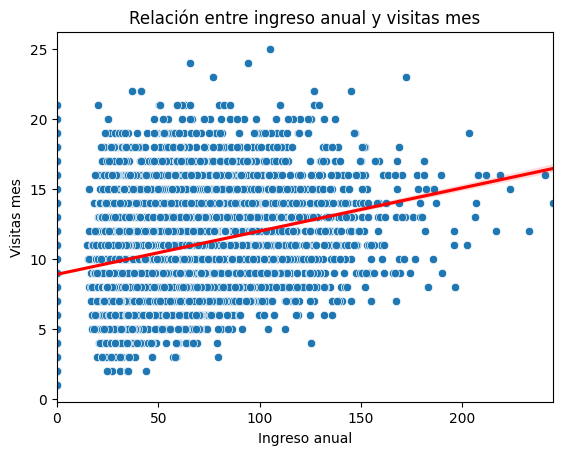

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='ingreso_anual', y='visitas_mes')
sns.regplot(data=df, x='ingreso_anual', y='visitas_mes', scatter=False, color='red')
plt.title("Relación entre ingreso anual y visitas mes")
plt.xlabel("Ingreso anual")
plt.ylabel("Visitas mes")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**

- Dirección: positiva. Al incrementar el ingreso anual de los usuarios, se observa una clara tendencia al aumento en el número de compras mensuales.

- Dispersión: baja. Los puntos se mantienen bastante compactos y agrupados siguiendo una franja diagonal bien definida.

- Los datos son altamente homogéneos, pero existen ligeros outliers aislados.

- Existe colinealidad, ya que ambas variables se mueven casi en una diagonal perfecta, es decir, aportan casi la misma información al modelo.

**ingreso_anual vs visitas_mes**
    
- Dirección: positiva. Conforme aumenta el ingreso anual de los usuarios, se observa una tendencia general al incremento en el número de visitas mensuales.

- Dispersión alta: Los puntos muestran una dispersión elevada y forman una nube de datos bastante amplia y extendida verticalmente.
    
- Se aprecian múltiples outliers dispersos en los extremos superior y derecho de la distribución.
    
- El patrón lineal es débil debido a la enorme variabilidad de los datos, lo que sugiere que el ingreso anual explica solo una parte pequeña del comportamiento de las visitas.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
pearson = df['ingreso_anual'].corr(df['compras_mes'], method='pearson')
print(f"Pearson compras:{pearson:.3f}")

spearman = df['ingreso_anual'].corr(df['compras_mes'], method='spearman')
print(f"Spearman compras:{pearson:.3f}")

Pearson compras:0.967
Spearman compras:0.967


In [ ]:
# Calcular correlación entre variables relevantes
pearson = df['ingreso_anual'].corr(df['visitas_mes'], method='pearson')
print(f"Pearson visitas:{pearson:.3f}")

spearman = df['ingreso_anual'].corr(df['visitas_mes'], method='spearman')
print(f"Spearman visitas:{spearman:.3f}")

Pearson visitas:0.337
Spearman visitas:0.321


In [ ]:
# Calcular correlación entre variables relevantes
pearson = df['ingreso_anual'].corr(df['gasto_publicidad_dirigida'], method='pearson')
print(f"Pearson gasto:{pearson:.3f}")

spearman = df['ingreso_anual'].corr(df['gasto_publicidad_dirigida'], method='spearman')
print(f"Spearman gasto:{spearman:.3f}")

Pearson gasto:0.197
Spearman gasto:0.185


✍️ **Comentario**:

**Observaciones de correlación**

**compras_mes vs ingreso_anual**
- Se obtuvo un coeficiente de correlación de Pearson de 0.967 entre compras_mes e ingreso_anual, lo que indica una relación lineal positiva muy fuerte. En términos prácticos, los clientes que realizan un mayor número de compras al mes tienden también a generar un mayor ingreso anual.
- Además, la elevada magnitud del coeficiente sugiere una posible colinealidad entre ambas variables

**ingreso_anual vs visitas_mes**
- Dirección: Positiva. A medida que aumenta el número de visitas mensuales, existe una tendencia a que también aumente el ingreso anual.
- Magnitud: moderada. Un valor de 0.321 indica una intensidad relativamente baja. Esto significa que los clientes que visitan más la plataforma no necesariamente generan ingresos anuales mucho mayores, aunque sí existe una tendencia en esa dirección.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
pb_premium, _ = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
print(f"Punto-biserial_mpremium: {pb_premium:.3f}")

pb_abandono, _ = pointbiserialr(df['abandono'], df['ingreso_anual'])
print(f"Punto_biserial_abandono: {pb_abandono:.3f}")

Punto-biserial_mpremium: 0.093
Punto_biserial_abandono: -0.003


✍️ **Comentario**:

**Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**
- Dirección: Positiva. Los clientes que pertenecen al programa Premium tienden a presentar un ingreso anual ligeramente mayor que los clientes que no son miembros.
- Magnitud: Baja. Un coeficiente de 0.093 indica que la asociación entre la membresía Premium y el ingreso anual es muy pequeña. Aunque existe una ligera tendencia positiva, la diferencia entre ambos grupos es reducida.

**abandono vs ingreso_anual**
- Dirección: Negativa. Los clientes que abandonan el servicio presentan, en promedio, un ingreso anual apenas inferior al de quienes permanecen.
- Magnitud: Prácticamente nula. Un coeficiente de -0.003 es extremadamente cercano a cero, lo que indica que no existe una relación estadísticamente relevante entre el abandono y el ingreso anual.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramers_v(df, col_1, col_2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col_1], df[col_2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))

    # mostrar resultados
    print(f"V de Cramér ({col_1} vs {col_2}): {coef_v:.3f}")

In [ ]:
# Aplicar V de Cramér en variables relevantes
col1 = "region"
col2 = "tipo_dispositivo"
col3 = "abandono"
col4 = "miembro_premium"

cramers_v(df, col1, col2)
cramers_v(df, col1, col3)
cramers_v(df, col1, col4)
cramers_v(df, col2, col3)
cramers_v(df, col2, col4)
cramers_v(df, col3, col4)

V de Cramér (region vs tipo_dispositivo): 0.012
V de Cramér (region vs abandono): 0.015
V de Cramér (region vs miembro_premium): 0.013
V de Cramér (tipo_dispositivo vs abandono): 0.007
V de Cramér (tipo_dispositivo vs miembro_premium): 0.020
V de Cramér (abandono vs miembro_premium): 0.120


✍️ **Comentario**:

**Observaciones V de Cramér**
El análisis mediante la V de Cramér evidencia asociaciones prácticamente nulas entre región, tipo de dispositivo, abandono y membresía premium, con valores entre 0.007 y 0.020 en la mayoría de las relaciones. La única asociación destacable corresponde a abandono y membresía premium (V = 0.20), aunque su magnitud sigue siendo débil. Estos resultados indican que las diferencias observadas en abandono y membresía premium no presentan una asociación importante con la región o el dispositivo utilizado. La relación entre abandono y membresía premium merece una exploración adicional, pero estos resultados no permiten establecer relaciones causales ni determinar que una variable provoque cambios en la otra.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Ingreso anual y compras mes

**Evidencia visual:**   Scatterplot y Heatmap

**Evidencia numérica:** Pearson = 0.967

**Interpretación**  Estas variables presentan una correlación muy fuerte, sin embargo, esta relación debe interpretarse con cautela, ya que ambas variables pueden reflejar el mismo fenómeno económico y presentar colinealidad. Por ello, este resultado es más relevante desde una perspectiva metodológica que como un hallazgo de negocio.

**No podemos afirmar**  Que un aumento en el número de compras cause directamente un incremento en el ingreso anual. La elevada correlación puede deberse a que ambas variables representan aspectos estrechamente relacionados del desempeño comercial, por lo que el resultado describe una asociación estadística y no una relación causal.

**Implicación de negocio** La fuerte correlación sugiere que ambas variables contienen información muy similar. En futuros análisis predictivos conviene evaluar si es necesario incluir ambas variables en un mismo modelo.

### Hallazgo 2 — ingreso anual y visitas mes

**Evidencia visual:**   Scatterplot y Heatmap

**Evidencia numérica:** Pearson: 0.337

**Interpretación** Los clientes que realizan un mayor número de visitas mensuales tienden a generar mayores ingresos anuales; sin embargo, la intensidad de la asociación es moderada, lo que indica que el número de visitas, por sí solo, explica una parte limitada de la variabilidad del ingreso anual.

**No podemos afirmar**  que incrementar el número de visitas mensuales provoque un aumento del ingreso anual, ya que los coeficientes de correlación únicamente describen una asociación estadística y no una relación de causa y efecto.

**Implicación de negocio**  Analizar el comportamiento de los clientes con muchas visitas y bajo ingreso anual podría ayudar a identificar oportunidades para optimizar la experiencia de compra, la personalización de ofertas o las estrategias de marketing.

### Hallazgo 3 — abandono y miembros premium

**Evidencia numérica:** V de Cramér: 0.120

**Interpretación** Se observa una asociación débil entre la condición de miembro Premium y el abandono. En el conjunto de datos, los clientes Premium presentan una menor proporción de abandono (4.36%) que los clientes no Premium (16.81%); sin embargo, la intensidad de la asociación es baja, lo que indica que la membresía, por sí sola, explica solo una pequeña parte del comportamiento de abandono.

**No podemos afirmar**  No podemos afirmar que la membresía Premium reduzca el abandono de los clientes, ya que la V de Cramér únicamente mide el grado de asociación entre ambas variables. Es posible que otros factores, como la satisfacción del cliente, la frecuencia de compra o el nivel de interacción con la plataforma, influyan simultáneamente en la permanencia del cliente.

**Implicación de negocio**  La asociación observada sugiere que la membresía Premium podría estar relacionada con una mayor retención de clientes. Sería recomendable analizar con mayor profundidad las características y el comportamiento de los clientes Premium para identificar prácticas que puedan replicarse en otros segmentos y validar esta hipótesis mediante análisis adicionales o estudios experimentales.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- La fuerte correlación observada entre **compras_mes** e **ingreso_anual** podría reflejar una posible colinealidad, por lo que ambas variables deben interpretarse con cautela en análisis predictivos.
- Es posible que existan variables no medidas (frecuencia de promociones, el valor promedio de compra, la antigüedad del cliente o factores estacionales) que influyan en el ingreso anual.
- Las correlaciones obtenidas representan el comportamiento del conjunto de datos analizado y podrían variar en otros periodos o poblaciones de clientes.

### **Próximos pasos**

- Probar segmentación adicional
  - [region]
  - [tipo_dispositivo]
  - [miembros premium]
  - [grupos de edad]
- Evaluar la posible multicolinealidad entre **compras_mes** e **ingreso_anual** mediante indicadores antes de utilizar ambas variables en modelos predictivos.
- Diseñar experimentos controlados, en campañas de marketing, para evaluar si cambios en la publicidad dirigida o en la estrategia comercial producen variaciones en el comportamiento de compra y, potencialmente, en el ingreso anual.
- Incorporar nuevas variables relacionadas con el comportamiento del cliente y el proceso de compra para obtener una comprensión más completa de los factores asociados al ingreso anual.
- Analizar la relación entre variables del comportamiento del cliente, como **miembro_premium** y **abandono**, que presentó una asociación débil (V de Cramér = 0.120), para explorar posibles estrategias de fidelización y retención de clientes.